In [1]:
from controller import *
from tasks import *
from run import *
from visualization import *

[I 09/02/26 14:11:09.496 47580] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


In [2]:
# initialize genesis
gs.init(backend=gs.cpu, logging_level="error")
dt = 0.01

### Simulation 1

We consider a simple task, consisting of three non conflicting cartesian task-space objectives.  
Task 1 is reaching a desired X, task 2 is reaching a desired Y and task 3 is following a sinusoidal trajectory in the Z coordinate.  
We do this with both the QP based controller and a traditional nullspace approach for comparison.  
We simulate gravity and we compensate for nonlinear effects.   

This experiment shows that the implementation from the paper works well and is comparable to traditional approaches in tracking performance while achieving lower total command torques.  
Nevertheless it does require significantly more computational effort. It may be possible to improve this by using a different solver.

Note that epsilon provides a way to penalize applied command torque. This is also an advantage over traditioal approach, as it gives you another tool to tweak.

In [3]:
# simulation parameters
show_viewer = False
T = 20
gravity = (0.0, 0.0, -9.81)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=20, D=10),
    YPositionTask(y_des=0.4, K=20, D=10),
    ZSinusoidalTask(z_center=0.4, amplitude=0.15, frequency=0.1, dt=dt, K=20, D=10),
]

# no artifical torque limits
torque_limits = None

# initialize results object
results = {}

In [4]:
# QP based controller (as in the paper)
results["QP"] = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

In [5]:
# traditional nullspace controller (as in the lecture)
results["Traditional"] = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

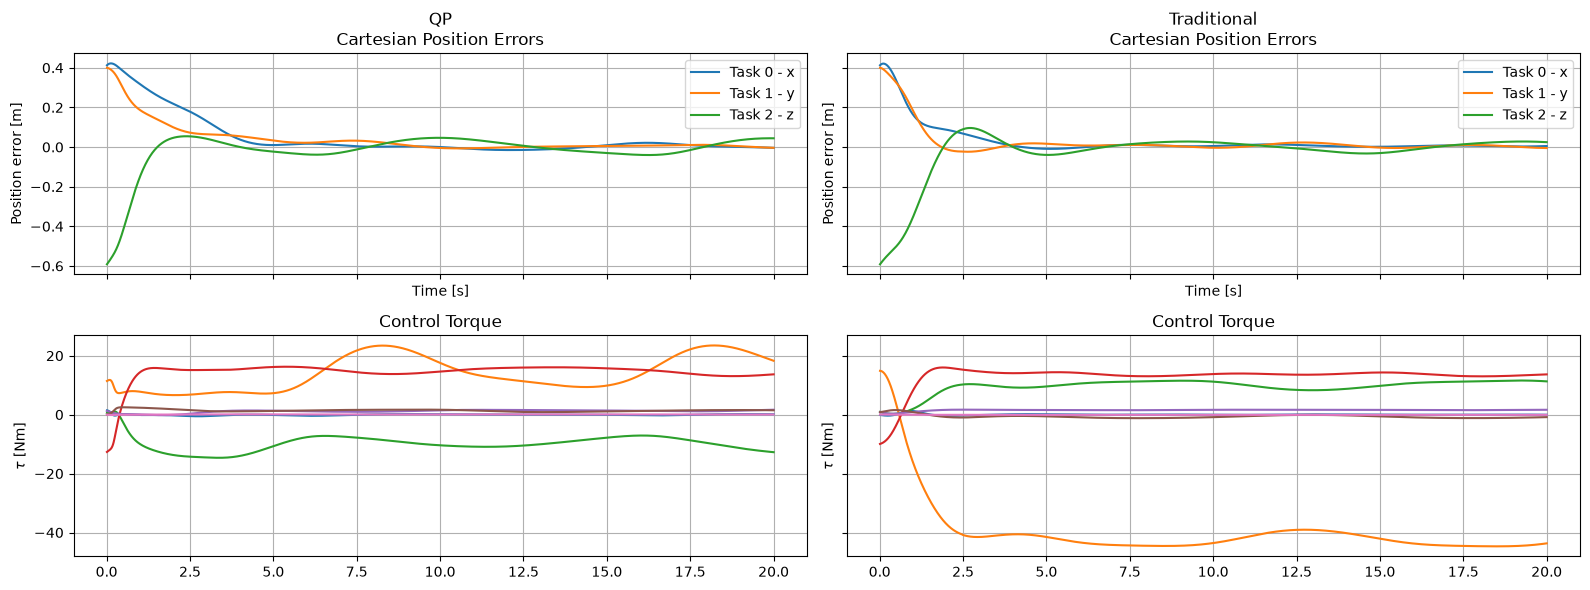

Metric                                      QP       Traditional
----------------------------------------------------------------
Computation time [ms]                   7.8578            0.0850
RMS torque [Nm]                         9.2518           17.4828
Task 0 RMSE [m]                         0.0108            0.0072
Task 0 Max Error [m]                    0.0214            0.0133
Task 1 RMSE [m]                         0.0142            0.0100
Task 1 Max Error [m]                    0.0323            0.0230
Task 2 RMSE [m]                         0.0303            0.0214
Task 2 Max Error [m]                    0.0466            0.0398


In [6]:
_ = plot(results=results, dt=dt, show_normalized_torque=False, sharey=True)
_ = show_metrics(results=results, dt=dt, transient_time=5)

### Simulation 2

In the second simulation we consider artificial torque limits in order to showcase the QPs capability of taking torque limit constraints into account.  
We also increase the gains of the tasks to ensure the torque limits do actually get reached.

For this experiment we do not simulate gravity as this makes it easier to see the direct effects of the torque limit on the tasks themselves.

It can be seen that the QP does achieve significantly better tracking performance in this experiment compared to the traditional approach, with lower maximum tracking error (after transient time). This is especially obvious at the times where the traditional approach reaches torque limits where the qp does not (around 6s to 7.5s and 16s to 17s). This showcases the methods potential in improving tracking performance if torque limits constraints become active.

This is achieved at the expense of getting a bit less smooth trajectory of the command torque, which could potentially be fixed by improving the QP cost function.

In [7]:
# simulation parameters
show_viewer = False
T = 20
gravity = (0.0, 0.0, 0.0)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=100, D=50),
    YPositionTask(y_des=0.4, K=100, D=50),
    ZSinusoidalTask(z_center=0.4, amplitude=0.5, frequency=0.1, dt=dt, K=100, D=50),
]

# artificially limit torque
torque_limits = [8, 8, 8, 8, 8, 8, 8]

# initialize results object
results = {}

In [8]:
# QP based controller (as in the paper)
results["QP"] = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

In [9]:
# traditional nullspace controller (as in the lecture)
results["Traditional"] = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

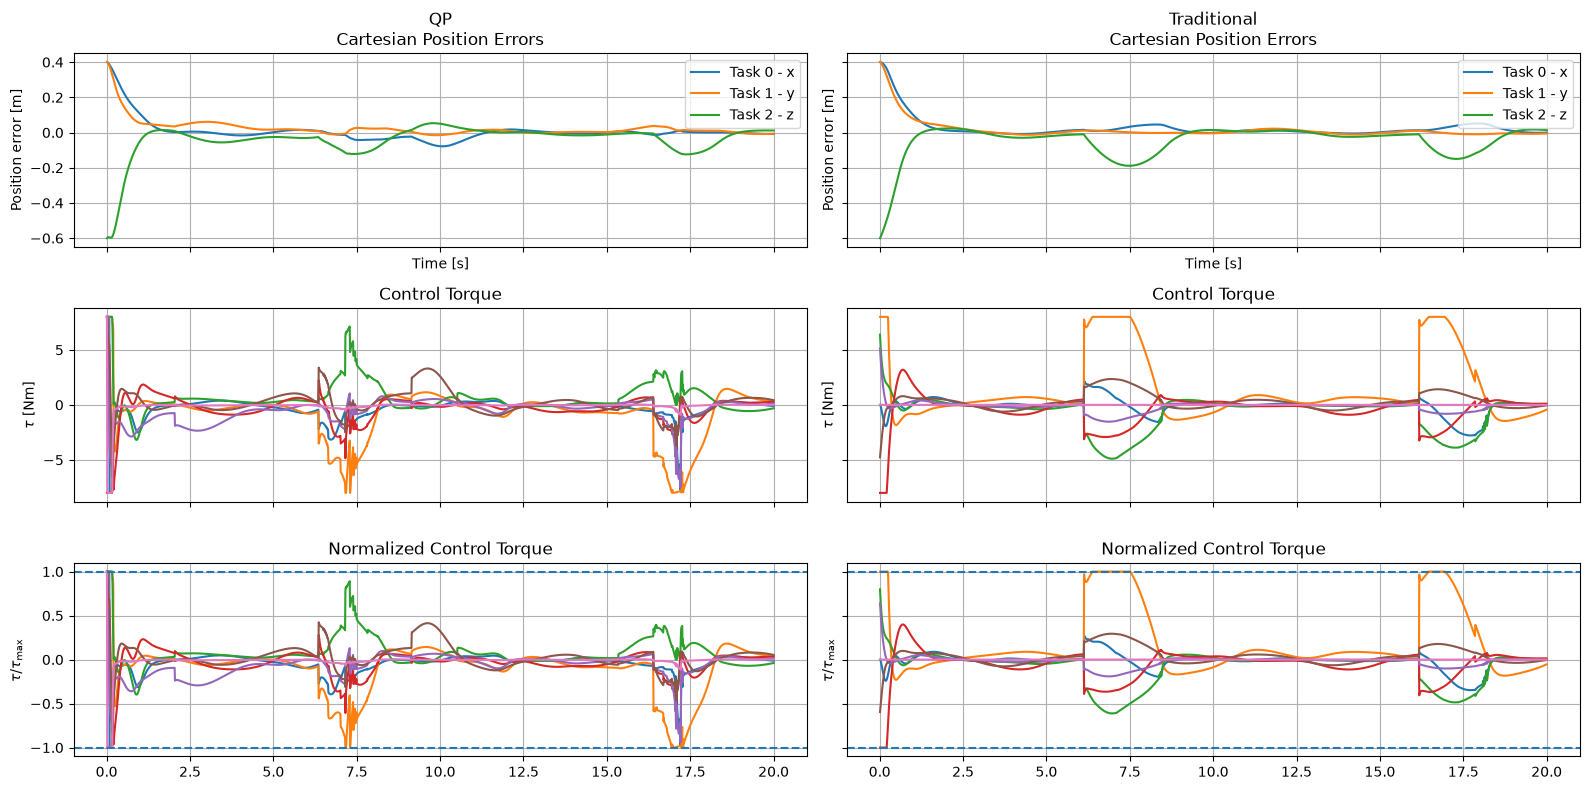

Metric                                      QP       Traditional
----------------------------------------------------------------
Computation time [ms]                   7.8360            0.0862
RMS torque [Nm]                         1.3447            1.6848
Task 0 RMSE [m]                         0.0253            0.0211
Task 0 Max Error [m]                    0.0782            0.0519
Task 1 RMSE [m]                         0.0144            0.0087
Task 1 Max Error [m]                    0.0375            0.0221
Task 2 RMSE [m]                         0.0522            0.0753
Task 2 Max Error [m]                    0.1241            0.1888


In [10]:
_ = plot(results=results, dt=dt, show_normalized_torque=True, sharey=True)
_ = show_metrics(results=results, dt=dt, transient_time=5)

### Simulation 3

In the third simulation we consider conflicting tasks to show that the qp does strictly hold the priority. 

For simplicity reasons we just command the same task of reaching an X position with two different values twice.

We are considering gravity, compensating for nonlinear effects and not artificially limiting the maximum applicable torque.

It can be seen clearly from the residual task errors that task 1 reaches while task 2 does not. This is to be expected as task 2 directly conflicts with the higher priority task 1.

In [11]:
# simulation parameters
show_viewer = False
T = 20
gravity = (0.0, 0.0, -9.81)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=20, D=10),
    XPositionTask(x_des=-0.4, K=20, D=10),
]

# no artificial torque limits
torque_limits = None

# initialize results object
results = {}

In [12]:
# QP based controller (as in the paper)
results["QP"] = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

In [13]:
# traditional nullspace controller (as in the lecture)
results["Traditional"] = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

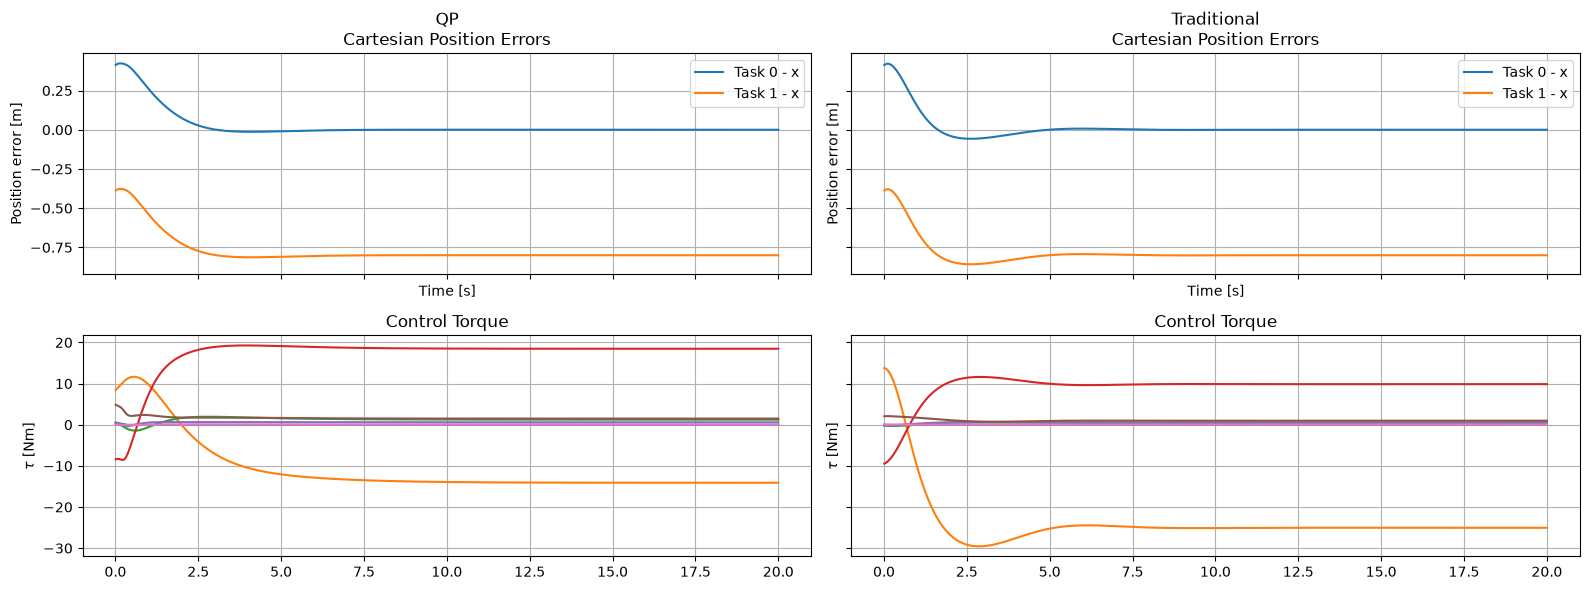

Metric                                      QP       Traditional
----------------------------------------------------------------
Computation time [ms]                   5.0790            0.0659
RMS torque [Nm]                         8.7819           10.1620
Task 0 RMSE [m]                         0.0020            0.0022
Task 0 Max Error [m]                    0.0096            0.0073
Task 1 RMSE [m]                         0.8006            0.7992
Task 1 Max Error [m]                    0.8096            0.8009


In [14]:
_ = plot(results=results, dt=dt, show_normalized_torque=False, sharey=True)
_ = show_metrics(results=results, dt=dt, transient_time=5)